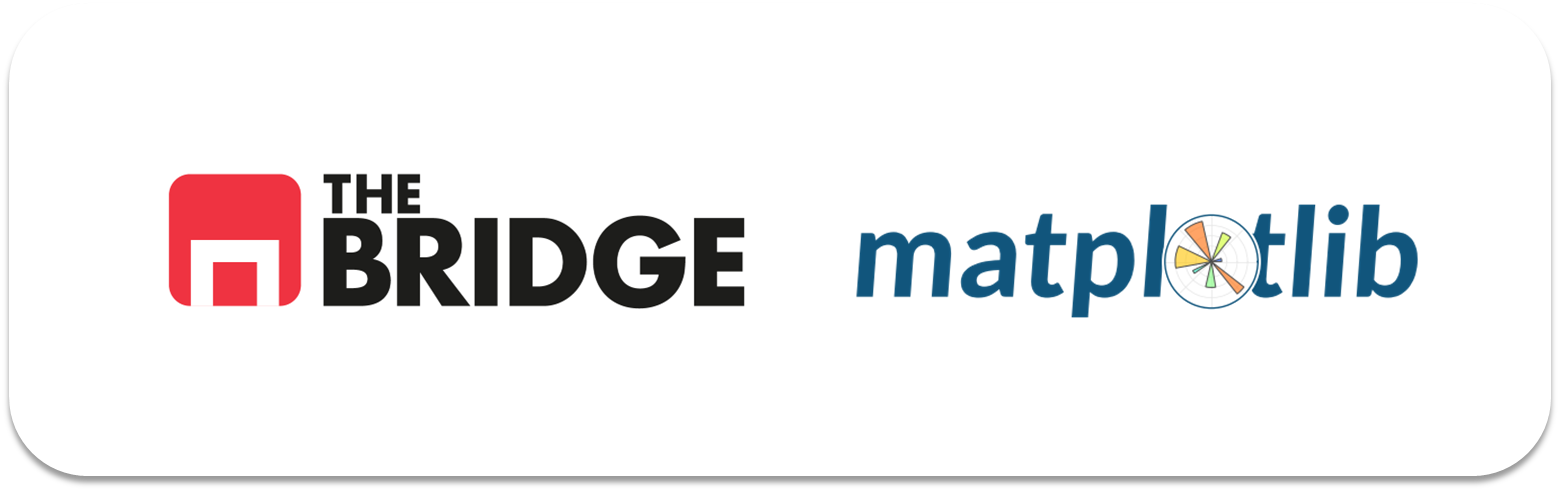

## PRACTICA OBLIGATORIA: **Visualización Básica**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

### Ejercicio 1

#### #1.1

- Carga el dataset de casas de California que está en la ruta "./data/california_cities.csv".  
- Muestra parte de su contenido y su descripción.  
- Deshazte de las filas con nulos.

In [45]:
# Cargar los datos.
df = pd.read_csv("./data/california_cities.csv")
# Mostrar contenido 
df.info()
# Eliminar filas con valores faltantes. 
df.dropna(inplace=True)


<class 'pandas.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          482 non-null    int64  
 1   city                482 non-null    str    
 2   latd                482 non-null    float64
 3   longd               482 non-null    float64
 4   elevation_m         434 non-null    float64
 5   elevation_ft        470 non-null    float64
 6   population_total    482 non-null    int64  
 7   area_total_sq_mi    480 non-null    float64
 8   area_land_sq_mi     482 non-null    float64
 9   area_water_sq_mi    481 non-null    float64
 10  area_total_km2      477 non-null    float64
 11  area_land_km2       478 non-null    float64
 12  area_water_km2      478 non-null    float64
 13  area_water_percent  477 non-null    float64
dtypes: float64(11), int64(2), str(1)
memory usage: 52.8 KB


In [46]:
# mostrar info 
print(df.head())
print("\n\n")
print(df.describe())

   Unnamed: 0         city       latd       longd  elevation_m  elevation_ft  \
0           0     Adelanto  34.576111 -117.432778        875.0        2871.0   
1           1  AgouraHills  34.153333 -118.761667        281.0         922.0   
4           4     Alhambra  34.081944 -118.135000        150.0         492.0   
5           5   AlisoViejo  33.575000 -117.725556        127.0         417.0   
6           6      Alturas  41.487222 -120.542500       1332.0        4370.0   

   population_total  area_total_sq_mi  area_land_sq_mi  area_water_sq_mi  \
0             31765            56.027           56.009             0.018   
1             20330             7.822            7.793             0.029   
4             83089             7.632            7.631             0.001   
5             47823             7.472            7.472             0.000   
6              2827             2.449            2.435             0.014   

   area_total_km2  area_land_km2  area_water_km2  area_water_p

#### #1.2  

Recrea la siguiente figura, para ello construye en apartados separados cada gráfico y luego haz un apartado en el que se junten los cuatro.  

Las figuras son:
1. Las ciudades más pobladas, con los numeros de las poblaciones (tendrás que usar texto y recordar que para centrarlos se necesita poner el argumento `ha` a "center" o investigar como funciona bar_label). Los colores de las barras deben tener un 50% de transparencia y ser: azul, gris, rojo, aceituna y marrón.  

2. Histograma del área total ocupada por las ciudades. (50 bins, fuente = "Arial", tamaño = 14, peso = "Bold", color azul acero o "steelblue")
3. El scatter de área de agua de un ciudad con su poblacion. Transparencia al 50% y color verde.
4. El boxplot de la altura de las ciudades.

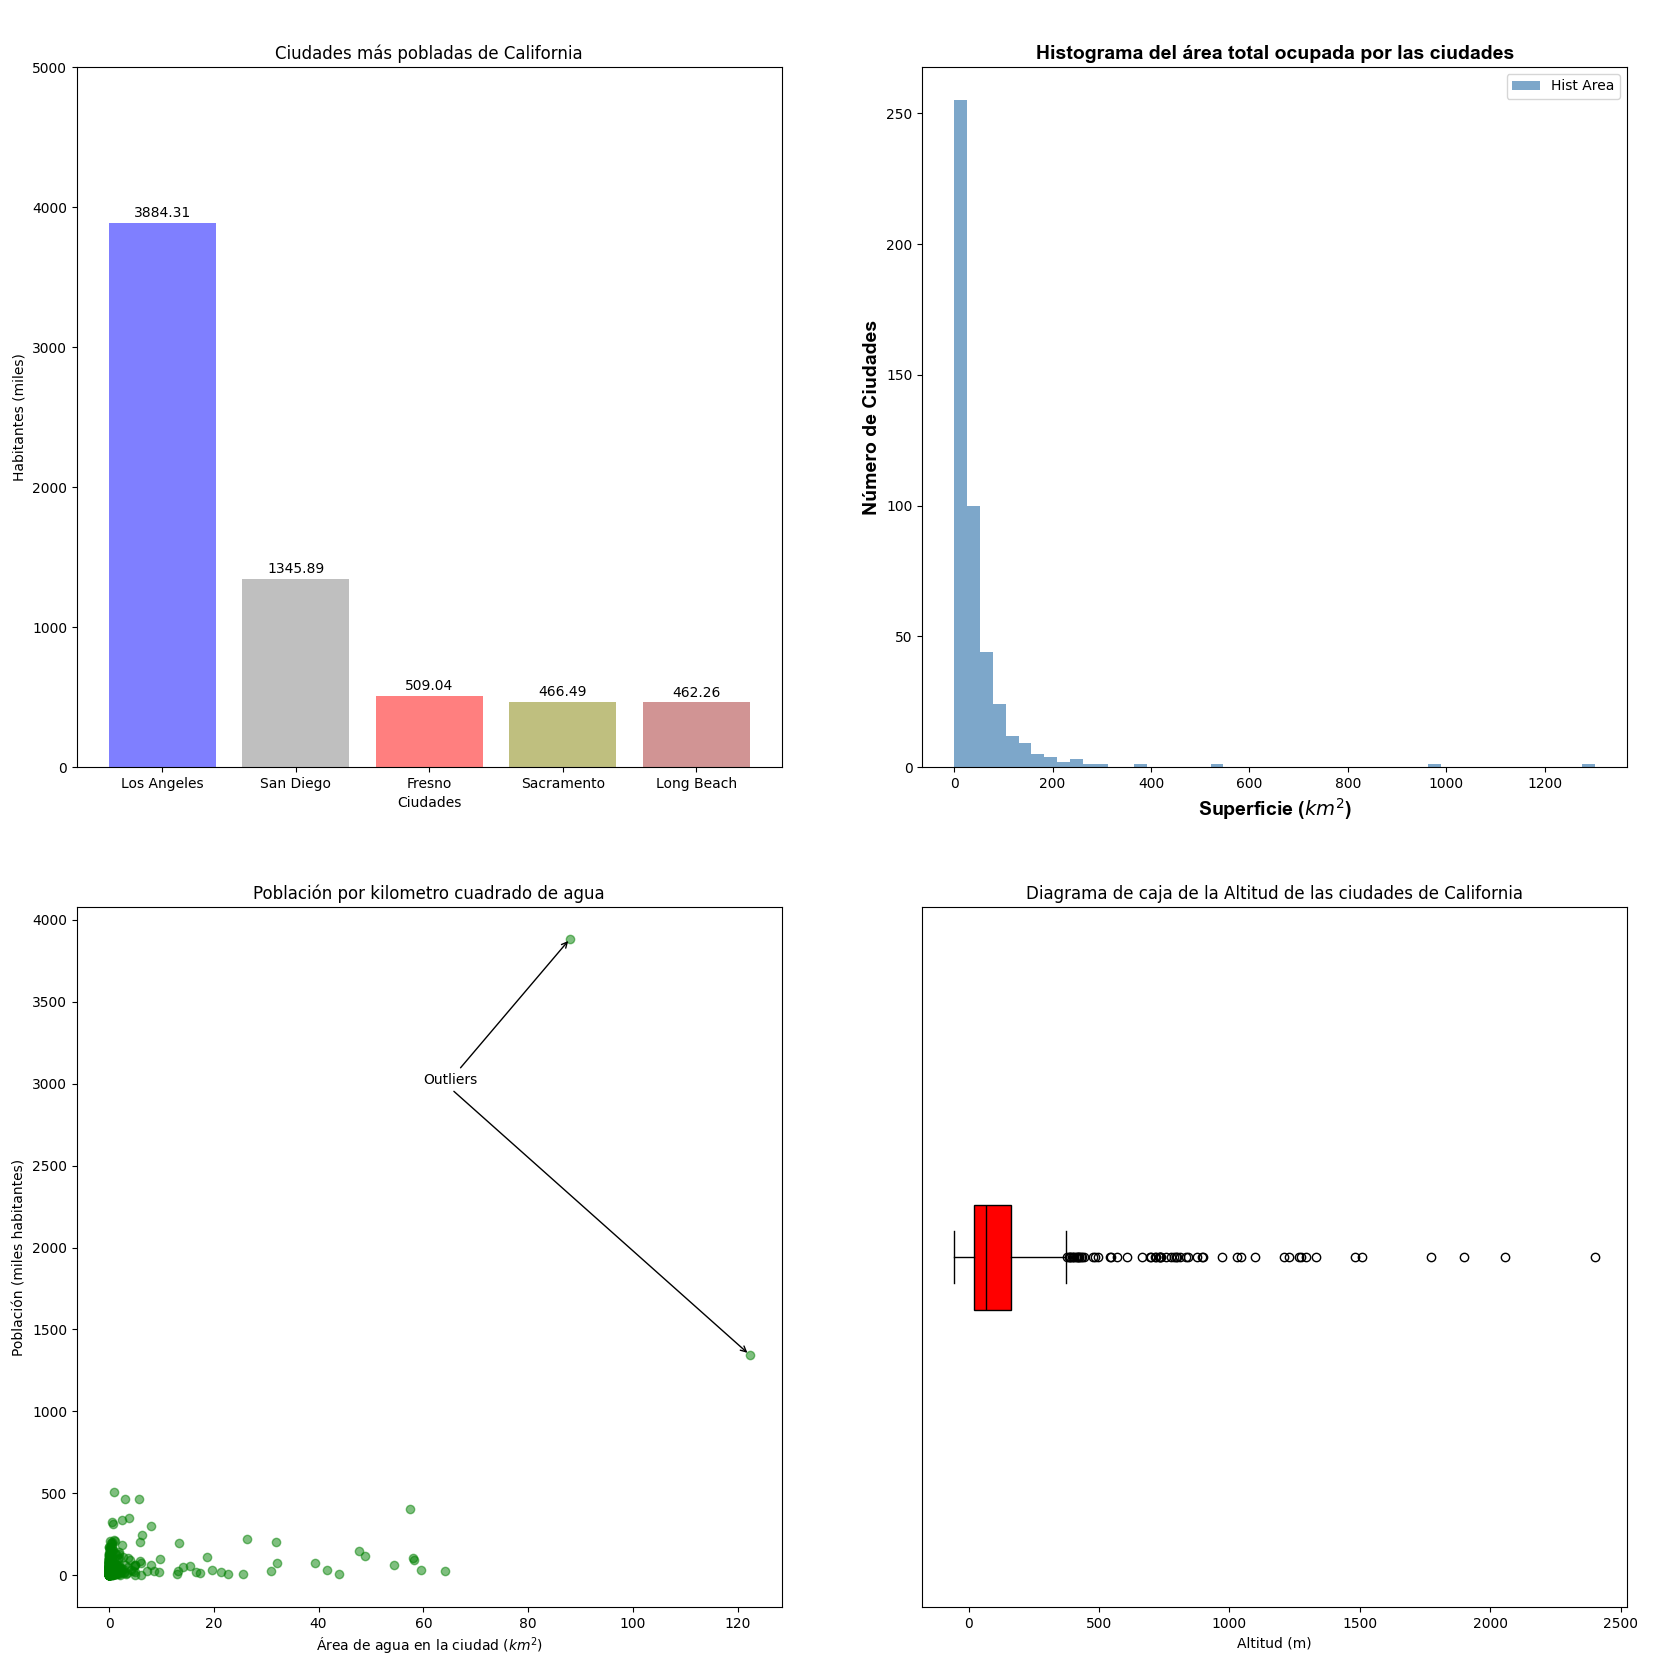

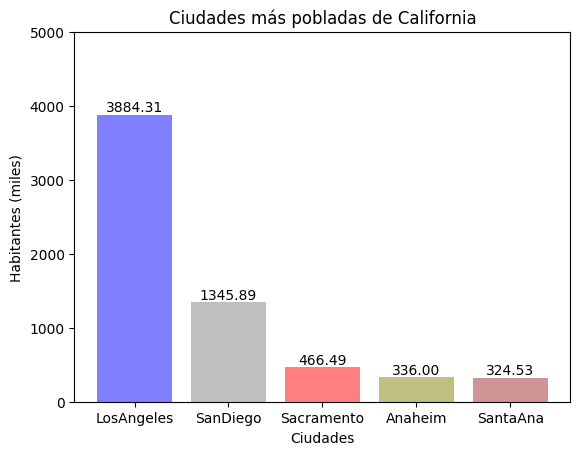

In [ ]:
# A: Bar chart, ciudades más pobladas

top5 = df.nlargest(5, "population_total")
fig_a, ax_a = plt.subplots()

# colores y alpha a 50%
bars = ax_a.bar(
    top5["city"],
    top5["population_total"] / 1000,  # población en miles como ejemplo
    color=["blue", "gray", "red", "olive", "brown"],
    alpha=0.5
)

# bar_label() lee las alturas de las barras y coloca el texto automáticamente.
ax_a.bar_label(bars, fmt="%.2f")

ax_a.set_title("Ciudades más pobladas de California")
ax_a.set_xlabel("Ciudades")
ax_a.set_ylabel("Habitantes (miles)")
ax_a.set_ylim(0, 5000)                        # opcional, para dar aire arriba

plt.show()


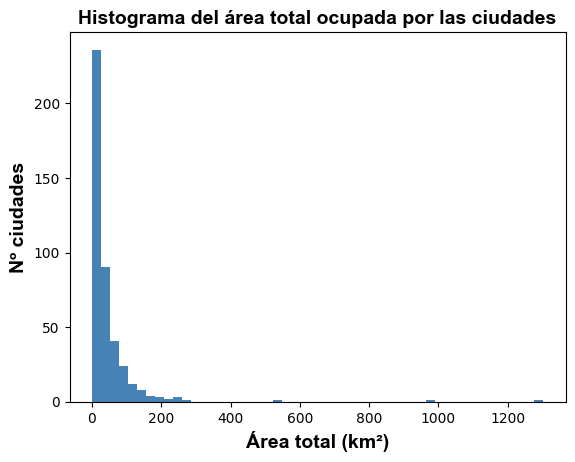

In [48]:
# B: Histograma, área total

fig_b, ax_b = plt.subplots()

# hist() divide el rango de valores en 50 intervalos (bins) y cuenta
# cuántas ciudades caen en cada uno. bins=50 da más resolución que el default (10).
ax_b.hist(df["area_total_km2"], bins=50, color="steelblue")

# fontname, fontsize y fontweight son propiedades de texto de matplotlib.
# Se aplican a cada elemento de texto de forma individual.
ax_b.set_xlabel("Área total (km²)", fontname="Arial", fontsize=14, fontweight="bold")
ax_b.set_ylabel("Nº ciudades", fontname="Arial", fontsize=14, fontweight="bold")
ax_b.set_title("Histograma del área total ocupada por las ciudades", fontname="Arial", fontsize=14, fontweight="bold")

plt.show()


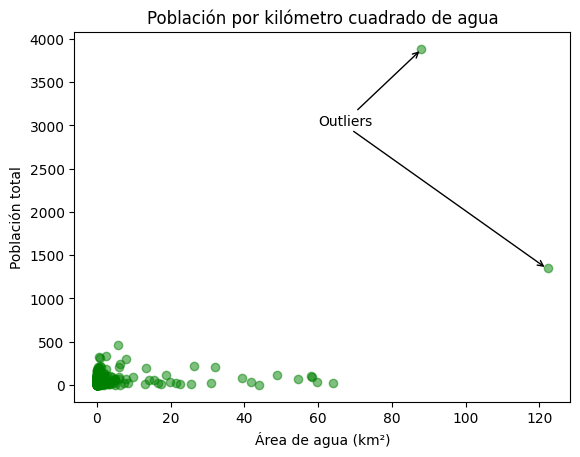

In [49]:
# C: Scatter, área de agua vs. población

fig_c, ax_c = plt.subplots()

# scatter de área de agua vs. población total (en miles para que no sean números tan grandes).
ax_c.scatter(df["area_water_km2"], df["population_total"] / 1000, alpha=0.5, color="green")

ax_c.set_title("Población por kilómetro cuadrado de agua")
ax_c.set_xlabel("Área de agua (km²)")
ax_c.set_ylabel("Población total")

# Anotación con dos flechas saliendo del mismo texto.
ax_c.annotate(
    "Outliers",
    xy=(88, 3880),                 # punta de la 1ª flecha (Los Angeles)
    xytext=(60, 3000),             # posición del texto
    arrowprops=dict(arrowstyle="->", color="black"),
)
ax_c.annotate(
    "",                            # sin texto: solo la flecha
    xy=(122, 1345),                # punta de la 2ª flecha (San Diego)
    xytext=(69, 2950),             # mismo origen que la anterior
    arrowprops=dict(arrowstyle="->", color="black"),
)

plt.show()

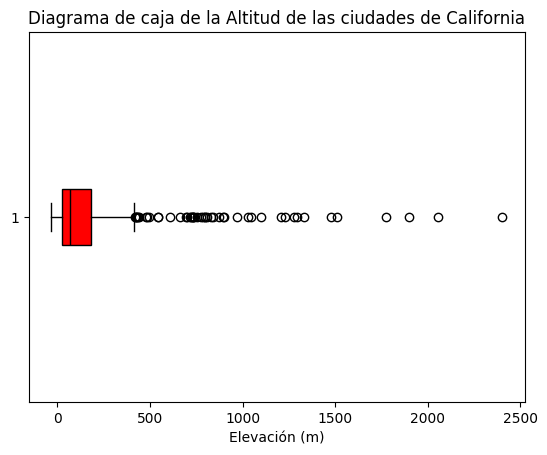

In [50]:
# D: Boxplot, altitud de las ciudades

fig_d, ax_d = plt.subplots()

# boxplot() resume la distribución en 5 números: mínimo, Q1, mediana, Q3, máximo.
# Los puntos fuera de los bigotes son outliers (ciudades a altitud extrema).
# Pasamos la columna como lista porque boxplot espera un iterable de datasets.
ax_d.boxplot(df["elevation_m"],
             vert=False,              
             patch_artist=True,     
             boxprops=dict(facecolor="red"),
             medianprops=dict(color="black")
)


ax_d.set_title("Diagrama de caja de la Altitud de las ciudades de California")
ax_d.set_xlabel("Elevación (m)")

plt.show()


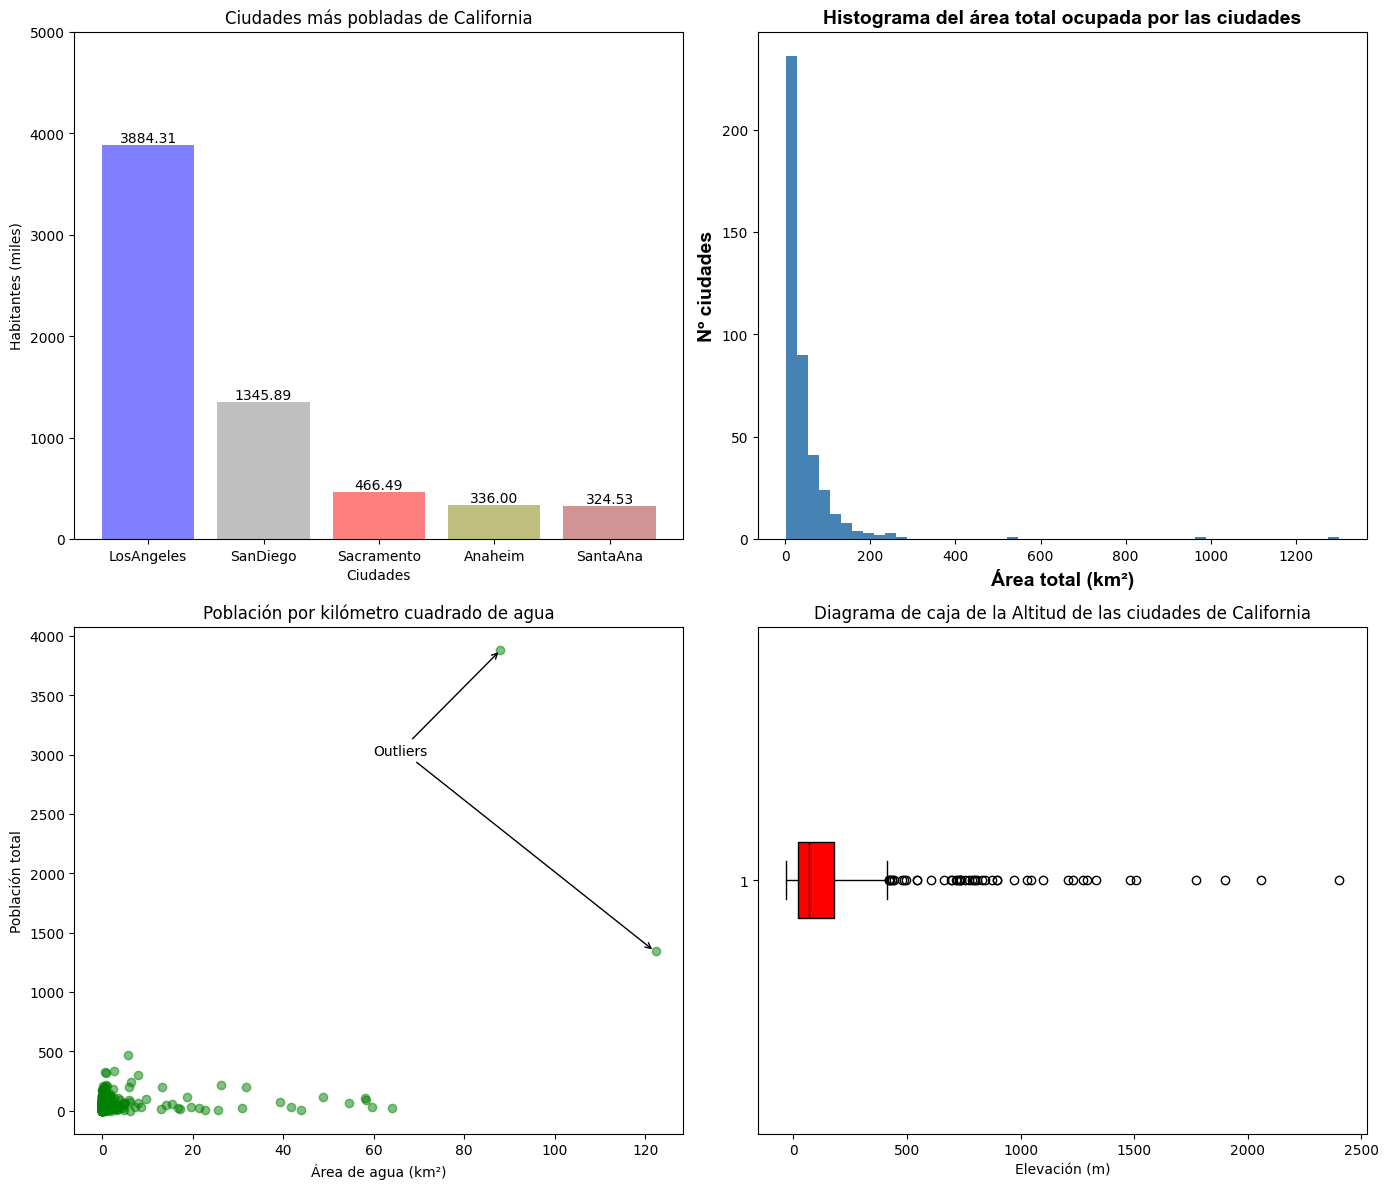

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
ax_a, ax_b, ax_c, ax_d = axes.flat   # aplana la matriz 2x2 → 4 axes en orden lectura

# --- A: bar chart ---
top5 = df.nlargest(5, "population_total")
bars = ax_a.bar(
    top5["city"],
    top5["population_total"] / 1000,  # población en miles como el ejemplo
    color=["blue", "gray", "red", "olive", "brown"],
    alpha=0.5
)
# bar_label() lee las alturas de las barras y coloca el texto automáticamente.
ax_a.bar_label(bars, fmt="%.2f")
ax_a.set_title("Ciudades más pobladas de California")
ax_a.set_xlabel("Ciudades")
ax_a.set_ylabel("Habitantes (miles)")
ax_a.set_ylim(0, 5000)           

# --- B: histograma ---
ax_b.hist(df["area_total_km2"], bins=50, color="steelblue")

ax_b.set_xlabel("Área total (km²)", fontname="Arial", fontsize=14, fontweight="bold")
ax_b.set_ylabel("Nº ciudades", fontname="Arial", fontsize=14, fontweight="bold")
ax_b.set_title("Histograma del área total ocupada por las ciudades", fontname="Arial", fontsize=14, fontweight="bold")

# --- C: scatter ---
ax_c.scatter(df["area_water_km2"], df["population_total"] / 1000, alpha=0.5, color="green")

ax_c.set_title("Población por kilómetro cuadrado de agua")
ax_c.set_xlabel("Área de agua (km²)")
ax_c.set_ylabel("Población total")

# Anotación con dos flechas saliendo del mismo texto.
ax_c.annotate(
    "Outliers",
    xy=(88, 3880),                 # punta de la 1ª flecha (Los Angeles)
    xytext=(60, 3000),             # posición del texto
    arrowprops=dict(arrowstyle="->", color="black"),
)
ax_c.annotate(
    "",                            # sin texto: solo la flecha
    xy=(122, 1345),                # punta de la 2ª flecha (San Diego)
    xytext=(69, 2950),             # mismo origen que la anterior
    arrowprops=dict(arrowstyle="->", color="black"),
)

# --- D: boxplot ---
ax_d.boxplot(df["elevation_m"],
             vert=False,              
             patch_artist=True,     
             boxprops=dict(facecolor="red"),
             medianprops=dict(color="black")
)
ax_d.set_title("Diagrama de caja de la Altitud de las ciudades de California")
ax_d.set_xlabel("Elevación (m)")

fig.tight_layout()
plt.show()

#### #1.3

Graba la figura en un archivo .png y sube el archivo a tu repositorio personal junto con el notebook.

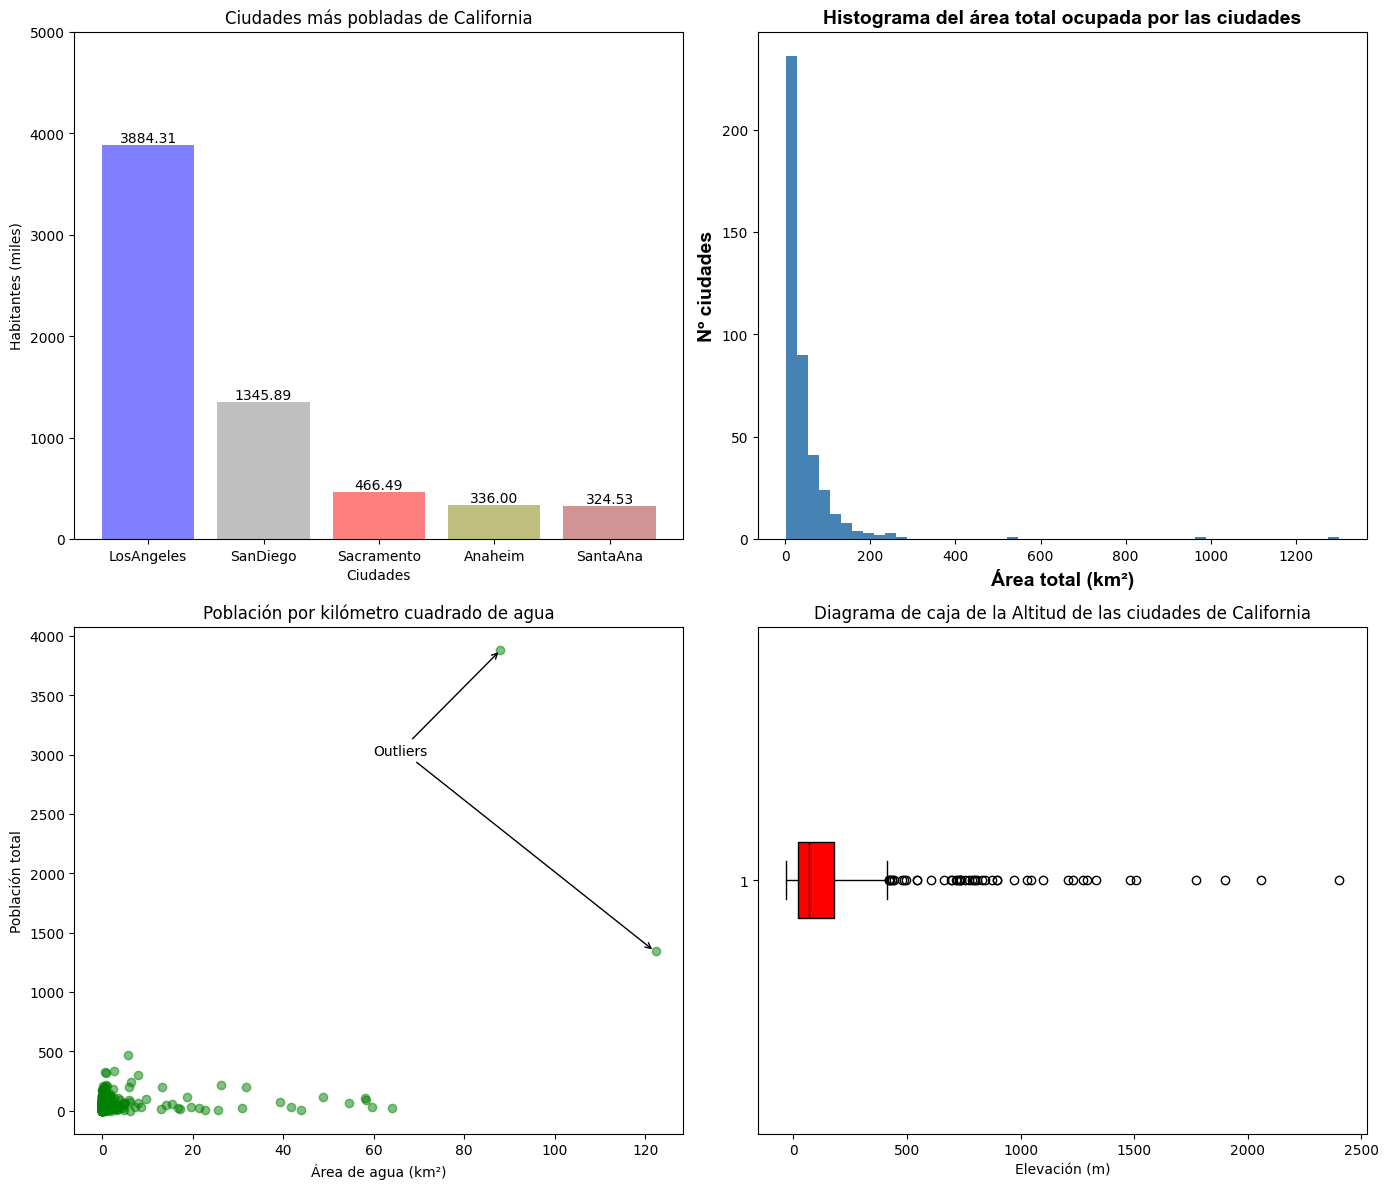

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
ax_a, ax_b, ax_c, ax_d = axes.flat   # aplana la matriz 2x2 → 4 axes en orden lectura

# --- A: bar chart ---
top5 = df.nlargest(5, "population_total")
bars = ax_a.bar(
    top5["city"],
    top5["population_total"] / 1000,  # población en miles como el ejemplo
    color=["blue", "gray", "red", "olive", "brown"],
    alpha=0.5
)
# bar_label() lee las alturas de las barras y coloca el texto automáticamente.
ax_a.bar_label(bars, fmt="%.2f")
ax_a.set_title("Ciudades más pobladas de California")
ax_a.set_xlabel("Ciudades")
ax_a.set_ylabel("Habitantes (miles)")
ax_a.set_ylim(0, 5000)           

# --- B: histograma ---
ax_b.hist(df["area_total_km2"], bins=50, color="steelblue")

ax_b.set_xlabel("Área total (km²)", fontname="Arial", fontsize=14, fontweight="bold")
ax_b.set_ylabel("Nº ciudades", fontname="Arial", fontsize=14, fontweight="bold")
ax_b.set_title("Histograma del área total ocupada por las ciudades", fontname="Arial", fontsize=14, fontweight="bold")

# --- C: scatter ---
ax_c.scatter(df["area_water_km2"], df["population_total"] / 1000, alpha=0.5, color="green")

ax_c.set_title("Población por kilómetro cuadrado de agua")
ax_c.set_xlabel("Área de agua (km²)")
ax_c.set_ylabel("Población total")

# Anotación con dos flechas saliendo del mismo texto.
ax_c.annotate(
    "Outliers",
    xy=(88, 3880),                 # punta de la 1ª flecha (Los Angeles)
    xytext=(60, 3000),             # posición del texto
    arrowprops=dict(arrowstyle="->", color="black"),
)
ax_c.annotate(
    "",                            # sin texto: solo la flecha
    xy=(122, 1345),                # punta de la 2ª flecha (San Diego)
    xytext=(69, 2950),             # mismo origen que la anterior
    arrowprops=dict(arrowstyle="->", color="black"),
)

# --- D: boxplot ---
ax_d.boxplot(df["elevation_m"],
             vert=False,              
             patch_artist=True,     
             boxprops=dict(facecolor="red"),
             medianprops=dict(color="black")
)
ax_d.set_title("Diagrama de caja de la Altitud de las ciudades de California")
ax_d.set_xlabel("Elevación (m)")

plt.tight_layout()

plt.savefig("practica_visualizacion_basica.png", bbox_inches="tight", dpi=150)
plt.show()
